# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: team 1
Created by Alex Hovakimyan(016319888), Gloria Duo(018038020), Julie Nguyen(015783807), Thang Cao(017740411)   
Last updated: 03/26/26 

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

data_path = Path('data') / 'baseline_dataset.parquet'
df = pd.read_parquet(data_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74583 entries, 0 to 74582
Data columns (total 66 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   subject_id               74583 non-null  int32         
 1   hadm_id                  74583 non-null  int32         
 2   stay_id                  74583 non-null  int32         
 3   first_careunit           74583 non-null  object        
 4   intime                   74583 non-null  datetime64[us]
 5   outtime                  74583 non-null  datetime64[us]
 6   admission_type           74583 non-null  category      
 7   admission_location       74583 non-null  category      
 8   insurance                74583 non-null  category      
 9   language                 74583 non-null  category      
 10  marital_status           74583 non-null  category      
 11  race_grouped             74583 non-null  category      
 12  is_male                  74583 n

In [27]:
df.describe()

,subject_id,hadm_id,stay_id,intime,outtime,age,ICU_endtime,ICU_time_to_event_hours,window_24h_end,min_val_heart_rate,...,mean_val_potassium,mean_val_sodium,mean_val_wbc,last_val_bilirubin,last_val_creatinine,last_val_lactate,last_val_platelets,last_val_potassium,last_val_sodium,last_val_wbc
count,7.458300e+04,7.458300e+04,7.458300e+04,74583,74583,74583.000000,74583,74583.000000,74583,74506.000000,...,73506.000000,73494.000000,73058.000000,33666.000000,73423.000000,44000.000000,73063.000000,73506.000000,73494.000000,73058.000000
mean,1.501234e+07,2.498545e+07,3.498883e+07,2153-10-16 05:04:54.564713,2153-10-20 14:55:51.850141,65.081842,2153-10-20 14:38:24.892159,105.558424,2153-10-17 05:04:54.564713,70.434169,...,4.182670,138.025095,12.243801,1.921636,1.436907,1.885439,203.021817,4.155639,138.250184,11.990368
min,1.000069e+07,2.000015e+07,3.000015e+07,2110-01-11 10:16:06,2110-01-12 17:17:47,18.000000,2110-01-12 17:17:47,24.000000,2110-01-12 10:16:06,0.000000,...,2.200000,101.590000,0.075000,0.000000,0.000000,0.000000,5.000000,1.900000,104.000000,0.100000
25%,1.251762e+07,2.249014e+07,3.250184e+07,2133-11-08 22:40:39.500000,2133-11-12 17:23:21,55.000000,2133-11-12 17:23:21,38.337500,2133-11-09 22:40:39.500000,60.000000,...,3.800000,135.571429,7.900000,0.400000,0.700000,1.100000,134.000000,3.800000,136.000000,7.700000
50%,1.501437e+07,2.498627e+07,3.497843e+07,2153-09-29 13:34:59,2153-10-02 17:49:16,67.000000,2153-10-02 17:49:16,60.038333,2153-09-30 13:34:59,69.000000,...,4.100000,138.000000,10.850000,0.700000,1.000000,1.600000,186.000000,4.100000,138.000000,10.600000
75%,1.753110e+07,2.746728e+07,3.747648e+07,2173-10-28 13:00:07,2173-11-02 02:17:51.500000,77.000000,2173-11-01 23:27:54,112.765833,2173-10-29 13:00:07,80.000000,...,4.500000,140.666667,14.733333,1.400000,1.500000,2.100000,251.000000,4.500000,141.000000,14.400000
max,1.999999e+07,2.999983e+07,3.999986e+07,2214-07-22 17:05:53,2214-07-26 17:13:57,103.000000,2214-07-26 17:13:57,5433.673889,2214-07-23 17:05:53,163.000000,...,33.920000,266.428571,338.625000,78.000000,36.400000,26.300000,2001.000000,10.400000,186.000000,378.300000
std,2.889338e+06,2.882668e+06,2.884757e+06,NaN,NaN,16.362802,NaN,139.889750,NaN,15.342845,...,0.573956,4.879999,8.739114,4.452024,1.510104,1.473507,107.161892,0.562299,4.871370,8.510033


In [28]:
df.isnull().sum()

subject_id                0
hadm_id                   0
stay_id                   0
first_careunit            0
intime                    0
                      ...  
last_val_lactate      30583
last_val_platelets     1520
last_val_potassium     1077
last_val_sodium        1089
last_val_wbc           1525
Length: 66, dtype: int64

In [29]:
df['first_careunit'] = (
    df['first_careunit']
    .str.lower()
    .str.strip()
    .astype('category')
)
df.first_careunit.head()

0                  medical intensive care unit (micu)
1                 surgical intensive care unit (sicu)
2    medical/surgical intensive care unit (micu/sicu)
3                  medical intensive care unit (micu)
4        cardiac vascular intensive care unit (cvicu)
Name: first_careunit, dtype: category
Categories (17, object): ['cardiac vascular intensive care unit (cvicu)', 'coronary care unit (ccu)', 'intensive care unit (icu)', 'med/surg', ..., 'surgery/trauma', 'surgery/vascular/intermediate', 'surgical intensive care unit (sicu)', 'trauma sicu (tsicu)']

Converts first_careunit to lowercase, removes extra spaces, and changes it to a category instead of object for consistency and efficiency.

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
high_missing = ['min_val_temperature', 'max_val_temperature', 'mean_val_temperature', 'last_val_temperature']
df = df.drop(columns=high_missing)

Drop the temperature columns since they are almost entirely missing.

In [32]:
bilirubin_cols = [col for col in df.columns if 'bilirubin' in col]
df = df.drop(columns=bilirubin_cols)

more than half the data is gone → unreliable

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

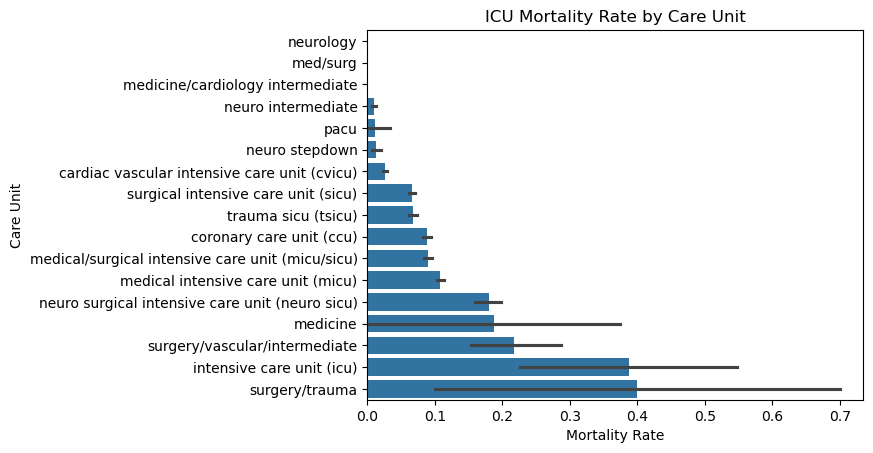

In [33]:
# How does ICU mortality vary by first care unit?
import seaborn as sns
import matplotlib.pyplot as plt

order = df.groupby('first_careunit', observed=True)['ICU_mortality'].mean().sort_values().index

sns.barplot(
    data=df,
    y='first_careunit',
    x='ICU_mortality',
    order=order
)

plt.title('ICU Mortality Rate by Care Unit')
plt.ylabel('Care Unit')
plt.xlabel('Mortality Rate')
plt.show()

### Insights
1. ICU mortality rates vary substantially across care units, with surgery/trauma and general ICU units showing the highest mortality.  
2. Specialized units such as neurology and intermediate care units tend to have lower mortality rates.  
3. This variation likely reflects differences in patient severity and case complexity across different types of care units.

### Q3: Come up with a another unique question. This question must use map() or apply()

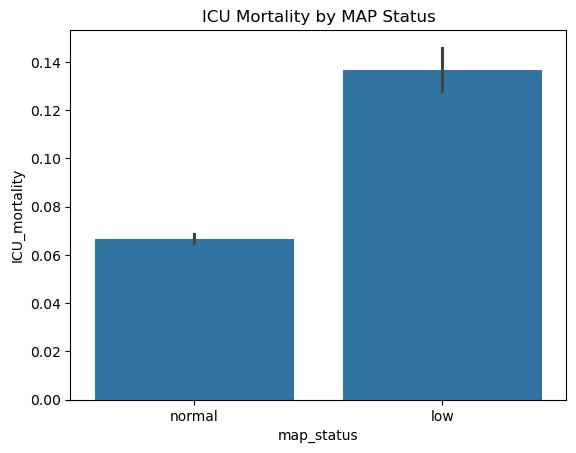

In [34]:
# Does abnormal mean arterial pressure (MAP) status affect ICU mortality?
# classify MAP using apply
df['map_status'] = df['mean_val_map'].apply(
    lambda x: 'low' if x < 65 else 'normal'
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x='map_status',
    y='ICU_mortality'
)

plt.title('ICU Mortality by MAP Status')
plt.show()

### Insights
1. Patients with low mean arterial pressure (MAP < 65 mmHg) have a substantially higher ICU mortality rate compared to those with normal MAP.  
2. This suggests that hypotension is strongly associated with increased risk of death in ICU patients.  
3. The finding aligns with clinical expectations, as low MAP indicates hemodynamic instability and poor organ perfusion.


### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

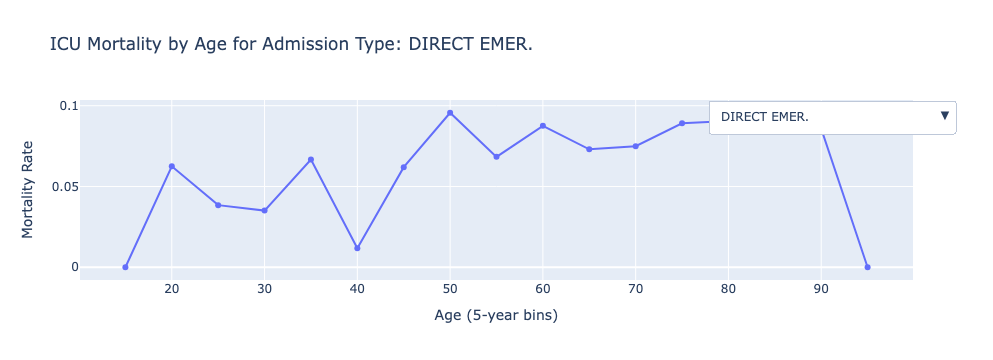

In [9]:
# How does ICU mortality change with different admission types and ages?
import plotly.graph_objects as go

# filter and prep
df_filtered = df[df['age'] <= 100].copy()
df_filtered['age_bin'] = (df_filtered['age'] // 5) * 5

age_adm = (
    df_filtered.groupby(['age_bin', 'admission_type'], observed=True)['ICU_mortality']
    .mean()
    .reset_index()
)

admission_types = age_adm['admission_type'].unique()

fig = go.Figure()

for i, adm in enumerate(admission_types):
    adm_df = age_adm[age_adm['admission_type'] == adm]
    fig.add_trace(
        go.Scatter(
            x=adm_df['age_bin'],
            y=adm_df['ICU_mortality'],
            mode='lines+markers',
            name=str(adm),
            visible=(i == 0)
        )
    )

buttons = []
for i, adm in enumerate(admission_types):
    visible = [False] * len(admission_types)
    visible[i] = True
    buttons.append(
        dict(
            label=str(adm),
            method='update',
            args=[
                {'visible': visible},
                {'title': f'ICU Mortality by Age for Admission Type: {adm}'}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            showactive=True,
            x=1.05,
            y=1
        )
    ],
    title=f'ICU Mortality by Age for Admission Type: {admission_types[0]}',
    xaxis_title='Age (5-year bins)',
    yaxis_title='Mortality Rate'
)

fig.show()

This interactive line plot uses a dropdown menu to let the viewer select an admission type and examine how ICU mortality changes across age within that group.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

Actually, for our current dataset that we're using, this is already joined on both hospital charts + ICU stay information. From the former, we borrowed information regarding patient demographics like age, race, language, etc. as well as lab results. From the latter, we extracted their length of stay + death or discharge status (this is where our target variable comes in) as well as ICU vitals information. The data from the relevant modules was combined by:

1. Filtering for just ICU patients, who are a subset of hospital patients.
2. Joining hospital modules with ICU patients on the appropriate foreign keys.
3. Selecting (heuristically) what we expect to be the most important features. Note that we do perform stricter, more empirical feature selection later on!
4. Aggregating time-series information regarding labs and vital signs (instead of a very wide dataframe that varies in size depending on patient length of stay, we found the mean, min, max, and last values of each selected feature per patient stay).

You can see more on how the dataset was prepared by viewing the notebook "MIMIC_joings.ipynb".